## Network analysis of LLM-generated network

Giorgio Bolchi 

23/01/2026

Context:
- A netowrk of positive (synergies) and negative links (tradeoffs) between 187 targets of the European Green Deal (EGD) was generated using a Large Language Model (LLM). Detailed code is available at: https://github.com/giorgiobolchi/jrc-egd
- The generated links were reviewd by JRC experts.
- We now want to perform a network analysis on that data using the code previously developed by Verdiana Fronza




#### Import libraries

In [3]:

# import libraries
import sys
import os
import networkx as nx
import pandas as pd
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# import functions
sys.path.append(r'C:\Users\Giorgio\switchdrive\Private\JRC\network analysis\network analysis giorgio')
from functions_toolbox import (convert_data_to_verdiana_syntax,  # ↓ Functions I created to adapt my data to Verdiana's functions
                                build_node_to_thematic_area,
                                build_thematic_areas_dict,
                                clean_area_name,                                
                                create_network_with_thematic_areas, # ↓ Functions created by Verdiana 
                                analyze_connectivity, 
                                compute_eigenvector_centrality,
                                compute_in_degree_centrality,
                                compute_out_degree_centrality,
                                calculate_closeness_with_distance,
                                compute_betweenness,
                                compute_hits,
                                compute_edge_betweenness)


#### Convert data into Verdiana's data syntax

Input data: '1. all_links_corrected.xlsx'
- '0. inter_TA_links_expert_corrected.xlsx' = inter-TA links that have been generated using a LLM and then reviewed by experts
- '0. intra_TA_link.xlsx' =  intra-TA links manually defined by Giorgio 

In [ ]:
# Load all the data
data_dir = r"C:\Users\Giorgio\switchdrive\Private\JRC\network analysis\network analysis giorgio\1. all_links_corrected.xlsx"
all_data = pd.read_excel(data_dir)

# Convert my dataset to Verdiana's data syntax so I can just plug my data into her functions
edge_list, nodes_df = convert_data_to_verdiana_syntax(all_data)
node_to_area = build_node_to_thematic_area(all_data)
thematic_areas = build_thematic_areas_dict(node_to_area)
node_to_area_clean = {n: clean_area_name(a) for n, a in node_to_area.items()}
thematic_areas = build_thematic_areas_dict(node_to_area_clean)


# Define thematic areas and their colors
thematic_areas_colors = {
            "TA1 - Climate ambition": "#FF9999",
            "TA2 - Clean, affordable and secure energy": "#99FF99",
            "TA3 - Industrial strategy for a clean and circular economy": "#9999FF",
            "TA4 - Sustainable and smart mobility": "#FFFF99",
            "TA5 - Greening the Common Agricultural Policy / Farm to Fork Strategy": "#FFCC99",
            "TA6 - Preserving and protecting biodiversity": "#CC99FF",
            "TA7 - Towards a zero-pollution ambition for a toxic free environment": "#99FFFF"
        }


# Create separate DataFrames for synergies and trade-offs
edge_list_synergies = edge_list[edge_list['Interlink Type'] == '+'].copy()
edge_list_tradeoffs = edge_list[edge_list['Interlink Type'] == '-'].copy()



#### Generate networks

The following functions were retrieved from Verdiana's script.

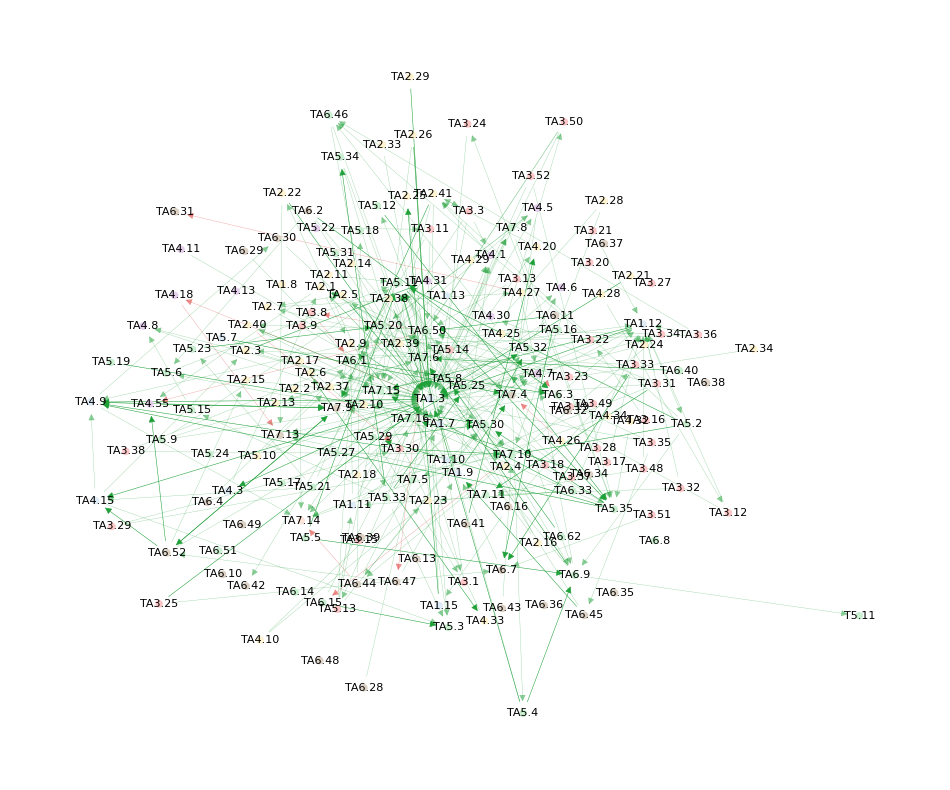

In [3]:
# synergies and tradeoffs altogether

network, network_undirected, network_rev, pos = create_network_with_thematic_areas(edge_list, 
                                                                                   nodes_df, 
                                                                                   thematic_areas, 
                                                                                   directed=True, 
                                                                                   visualize=True,
                                                                                   filename="network.gexf",
                                                                                   save_visualization=False, 
                                                                                   visualization_filename="network_visualization.png")

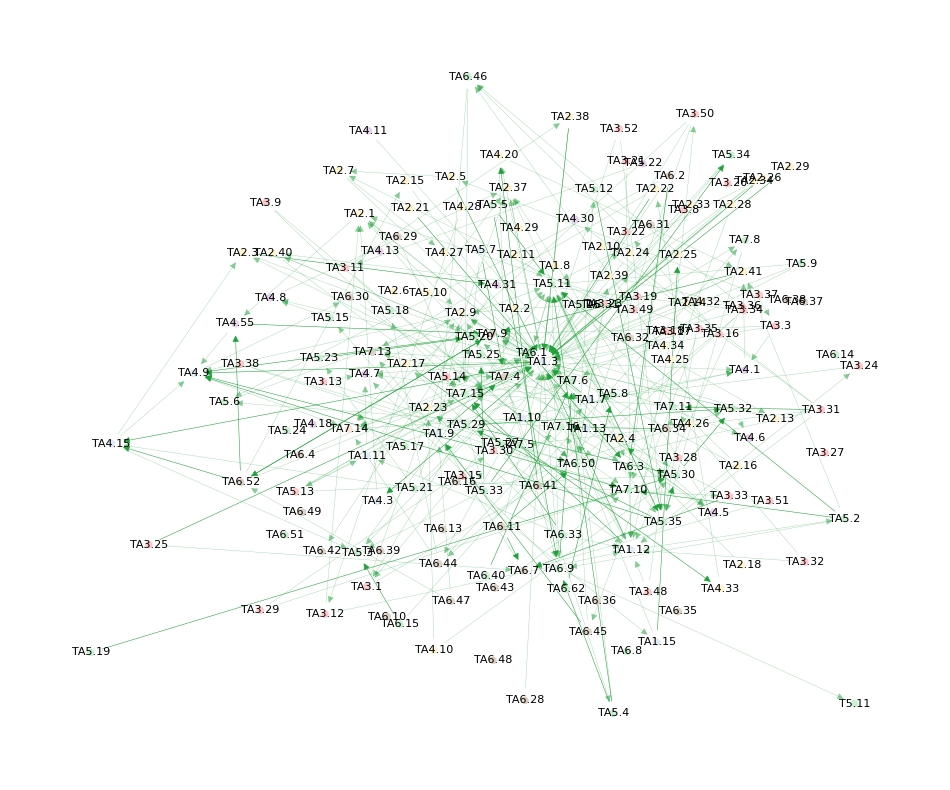

In [4]:
# synergies only

network_syn, network_syn_undirected, network_syn_rev, pos_syn = create_network_with_thematic_areas(edge_list_synergies, 
                                                                                   nodes_df, 
                                                                                   thematic_areas, 
                                                                                   directed=True, 
                                                                                   visualize=True,
                                                                                   filename="network_syn.gexf",
                                                                                   save_visualization=False, 
                                                                                   visualization_filename="network_syn_visualization.png")

Network visualization saved as: network_trade_visualization.png


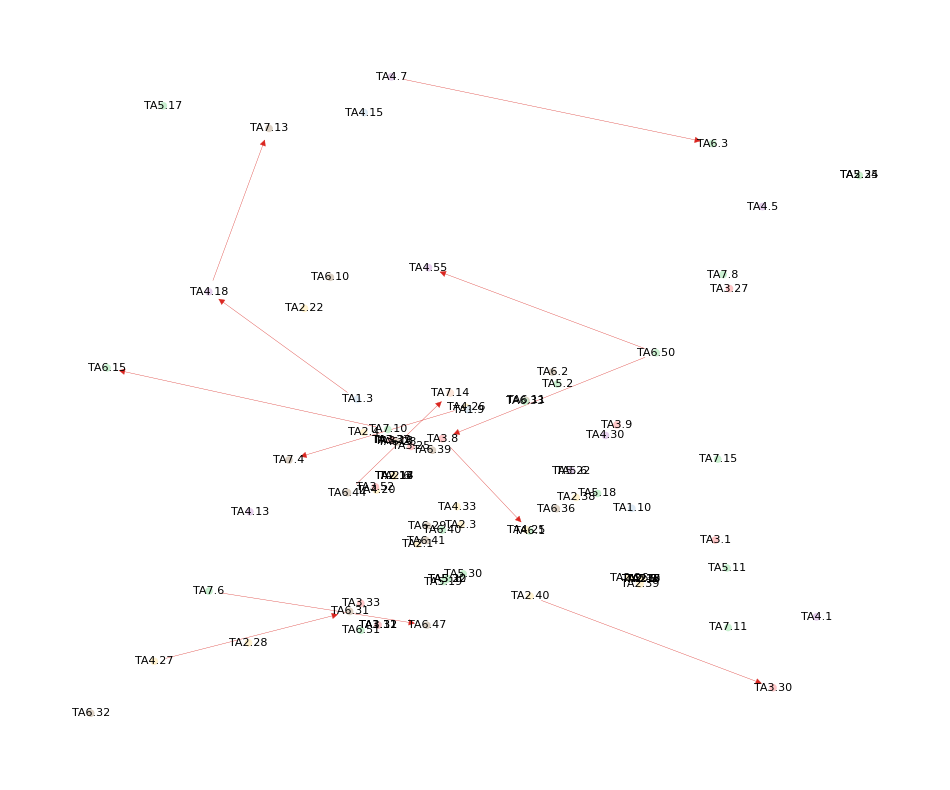

In [ ]:
# tradeoffs only

network_trade, network_trade_undirected, network_trade_rev, pos_tradeo = create_network_with_thematic_areas(edge_list_tradeoffs, 
                                                                                   nodes_df, 
                                                                                   thematic_areas, 
                                                                                   directed=True, 
                                                                                   visualize=True,
                                                                                   filename="network_trade.gexf",
                                                                                   save_visualization=True, 
                                                                                   visualization_filename="network_trade_visualization.png")


# note: there is something with the 'create_network_with_thematic_areas' function defined by Verdiana that I did not understand, because it visualises only a few tradeoffs even though there are many more in the data. It must be something related to how the thickness of the edges is defined, soemthing with the alpha value.

### Network analyses

In [ ]:

# Compute Connectivity

#for synergies network
synergies_results = analyze_connectivity(network_syn, "Synergies Network")

# for tradeoffs network
tradeoffs_results = analyze_connectivity(network_trade, "tradeoffs Network")


Synergies Network is NOT strongly connected.
Nodes not in the largest SCC (141 nodes): {'TA6.39', 'TA2.28', 'TA5.27', 'TA3.34', 'TA3.8', 'TA3.18', 'TA3.37', 'TA3.23', 'TA3.25', 'TA5.31', 'TA5.22', 'TA3.15', 'TA2.11', 'TA3.16', 'TA3.49', 'TA2.33', 'TA4.32', 'TA2.34', 'TA3.36', 'TA6.2', 'TA6.16', 'TA3.19', 'TA3.35', 'TA6.31', 'TA3.17', 'TA2.29', 'T5.11', 'TA5.16', 'TA4.18', 'TA3.20', 'TA4.34', 'TA6.34', 'TA6.40', 'TA6.38', 'TA6.37', 'TA3.22', 'TA6.32', 'TA2.24', 'TA2.26', 'TA3.48', 'TA2.14'}
Nodes not fully connected in both directions: {'TA1.13', 'TA2.18', 'TA2.5', 'TA7.10', 'TA4.8', 'TA5.27', 'TA3.34', 'TA7.8', 'TA5.30', 'TA3.21', 'TA3.11', 'TA3.52', 'TA2.39', 'TA1.12', 'TA3.16', 'TA4.25', 'TA4.3', 'TA1.15', 'TA5.29', 'TA6.47', 'TA6.2', 'TA3.38', 'TA1.7', 'TA4.31', 'TA2.29', 'T5.11', 'TA7.13', 'TA5.34', 'TA5.17', 'TA7.5', 'TA1.8', 'TA6.37', 'TA5.5', 'TA5.11', 'TA2.17', 'TA5.10', 'TA5.18', 'TA6.51', 'TA6.1', 'TA4.1', 'TA2.22', 'TA5.20', 'TA4.9', 'TA5.23', 'TA2.26', 'TA5.14', 'TA3.24', '

In [ ]:
# Compute Eigenvector Centrality Synergies

# For directed graphs nx.eigenvector_centrality is “left” eigenvector centrality 
# which corresponds to the in-edges in the graph. For out-edges eigenvector centrality use reversed df

eigen_df_dir = compute_eigenvector_centrality(network_syn, "Synergies Network")
eigen_df_dir_out = compute_eigenvector_centrality(network_syn_rev, "Reversed Synergies Network")

# Compute Eigenvector Centrality Tradeoffs
eigen_df_dir_trade = compute_eigenvector_centrality(network_trade, "Tradeoffs Network")
eigen_df_dir_out_trade = compute_eigenvector_centrality(network_trade_rev, "Reversed Tradeoffs Network")



In [8]:
# Compute In-Degree Centrality
in_degree_df = compute_in_degree_centrality(network_syn, "Synergies Network")
in_degree_tradeoffs_df = compute_in_degree_centrality(network_trade, "Tradeoffs Network")


# Display top 10 results
print(in_degree_df.head(10))
print(in_degree_tradeoffs_df.head(10))



    target  in_degree_centr
3    TA1.3         0.353591
4   TA5.11         0.160221
5    TA6.1         0.143646
87   TA7.6         0.132597
42   TA2.9         0.116022
8   TA7.15         0.110497
66  TA3.30         0.110497
19   TA7.4         0.104972
6    TA7.9         0.093923
14   TA7.5         0.093923
    target  in_degree_centr
17   TA6.1         0.123596
35  TA7.14         0.078652
24   TA3.8         0.044944
13  TA1.10         0.033708
12  TA5.30         0.033708
15  TA7.13         0.033708
9   TA4.30         0.033708
2    TA4.5         0.033708
57   TA3.9         0.033708
22  TA6.50         0.033708


In [9]:

# Compute Out-Degree Centrality for
out_degree_df = compute_out_degree_centrality(network_syn, "Synergies Network")
out_degree_df_trade = compute_out_degree_centrality(network_trade, "Tradeoffs Network")

# Display top 10 results
print(out_degree_df.head(10))
print(out_degree_df_trade.head(10))

     target  out_degree_centr
3     TA1.3          0.220994
5     TA6.1          0.049724
29   TA6.33          0.049724
134  TA5.33          0.049724
23   TA5.25          0.044199
0    TA2.41          0.044199
67   TA6.52          0.044199
107   TA6.3          0.044199
94   TA5.35          0.044199
168  TA6.16          0.044199
    target  out_degree_centr
17   TA6.1          0.213483
16  TA2.38          0.033708
22  TA6.50          0.033708
57   TA3.9          0.033708
63  TA4.27          0.033708
12  TA5.30          0.022472
18  TA2.39          0.022472
39  TA6.39          0.022472
23  TA4.13          0.022472
24   TA3.8          0.022472


In [10]:
# Create df for synergies
closen_w_in_df_sorted, closen_w_out_df_sorted = calculate_closeness_with_distance(network_syn)
print(closen_w_in_df_sorted)
print(closen_w_out_df_sorted)

# Create df for tradeoffs
closen_w_in_df_sorted_trade, closen_w_out_df_sorted_trade = calculate_closeness_with_distance(network_trade)
print(closen_w_in_df_sorted_trade)
print(closen_w_out_df_sorted_trade)


     target  closen_centr_w_in
3     TA1.3           0.924297
65    TA4.9           0.777721
8    TA7.15           0.761186
4    TA5.11           0.739183
62   TA4.15           0.723255
..      ...                ...
168  TA6.16           0.000000
166  TA4.32           0.000000
172  TA6.32           0.000000
179  TA2.11           0.000000
181  TA5.31           0.000000

[182 rows x 2 columns]
     target  closen_centr_w_out
3     TA1.3            0.473107
48    TA1.7            0.413190
53   TA1.12            0.413190
30   TA2.26            0.411589
4    TA5.11            0.406563
..      ...                 ...
173  TA6.38            0.237466
148  TA6.29            0.236130
76   TA4.27            0.236045
162  TA4.29            0.222273
180   T5.11            0.000000

[182 rows x 2 columns]
    target  closen_centr_w_in
17   TA6.1           0.174351
24   TA3.8           0.142428
57   TA3.9           0.132188
80  TA2.37           0.127840
45   TA2.1           0.124844
..     ...      

In [11]:
# # Compute Betweenness for Synergie Network
between_wd_df = compute_betweenness(network_syn, use_distance=True, name="Synergies Network (Reciprocal Weight)")
# Compute Outgoing Betweenness Using Reversed Graph
between_wd_out_df = compute_betweenness(network_syn_rev, use_distance=True, name="Synergies Network (Outgoing)")


# Compute Betweenness for Trade-offs Network
between_wd_df_trade = compute_betweenness(network_trade, use_distance=True, name="Tradeoffs Network (Reciprocal Weight)")
# Compute Outgoing Betweenness Using Reversed Graph
between_wd_out_df_trade = compute_betweenness(network_trade_rev, use_distance=True, name="Tradeoffs Network (Outgoing)")



In [14]:
# Compute HITS for Synergies and Trade-Offs Networks
hits_auts_syn_df = compute_hits(network_syn, "Synergies Network")
hits_auts_trade_df = compute_hits(network_trade, "Tradeoffs Network")

# Display Top 10 Nodes by Hub and Authority Scores
print("\nTop Hubs (Synergies Network):")
print(hits_auts_syn_df.sort_values(by=['hub'], ascending=False).head(10))

print("\nTop Authorities (Synergies Network):")
print(hits_auts_syn_df.sort_values(by=['authority'], ascending=False).head(10))




Top Hubs (Synergies Network):
             hub  authority
TA1.3   0.030625   0.164361
TA2.26  0.021146  -0.000000
TA1.7   0.020613   0.004551
TA1.12  0.020430   0.010723
TA2.38  0.018864   0.001758
TA2.41  0.018789   0.007309
TA2.22  0.017793   0.001908
TA2.21  0.017326   0.001207
TA2.5   0.017125   0.001007
TA6.52  0.016211   0.001873

Top Authorities (Synergies Network):
             hub  authority
TA1.3   0.030625   0.164361
TA5.11  0.014817   0.060133
TA7.15  0.000034   0.042043
TA7.9   0.005522   0.038310
TA2.9   0.014920   0.030353
TA7.6   0.000619   0.029024
TA7.13  0.000938   0.023316
TA6.1   0.011347   0.021175
TA4.7   0.001982   0.020606
TA4.1   0.000552   0.019200


In [15]:
# Precompute distance attribute (1/weight) for synergies network
for u, v, d in network_syn.edges(data=True):
    d["distance"] = 1 / d["weight"] if d["weight"] > 0 else float("inf")

# Compute Edge Betweenness Centrality (Using Distance)
edge_betweenness_syn_df = compute_edge_betweenness(network_syn, use_distance=True, name="Synergies Network")

# Compute Edge Betweenness Centrality (Using Weight Directly)
edge_betweenness_syn_weight_df = compute_edge_betweenness(network_syn, use_distance=False, name="Synergies Network (Weight-Based)")

# Compute Edge Betweenness for Tradeoffs Network
for u, v, d in network_trade.edges(data=True):
    d["distance"] = 1 / d["weight"] if d["weight"] > 0 else float("inf")

edge_betweenness_trade_df = compute_edge_betweenness(network_trade, use_distance=True, name="Tradeoffs Network")

# Display top results
print(edge_betweenness_syn_df.head(10))
print(edge_betweenness_trade_df.head(10))


                 Edge  Betweenness Centrality
283   (TA1.12, TA1.3)                0.054461
454  (TA5.35, TA5.29)                0.032858
74    (TA7.9, TA6.52)                0.032093
155  (TA2.17, TA4.33)                0.029811
30    (TA1.3, TA5.35)                0.028352
31    (TA1.3, TA5.17)                0.027766
472   (TA5.32, TA1.3)                0.026779
530  (TA5.17, TA6.44)                0.025595
22    (TA1.3, TA4.31)                0.024507
100  (TA5.30, TA5.32)                0.023422
               Edge  Betweenness Centrality
46   (TA3.8, TA6.1)                0.037203
40  (TA6.50, TA3.8)                0.032335
3   (TA7.8, TA6.50)                0.025218
2    (TA4.5, TA7.8)                0.021598
12  (TA5.30, TA6.1)                0.016479
62   (TA2.1, TA6.1)                0.016479
45   (TA3.8, TA1.3)                0.015231
18  (TA6.1, TA2.38)                0.014981
68  (TA6.31, TA2.1)                0.012734
30   (TA6.1, TA3.9)                0.012609


#### Export data

In [16]:
# SYNERGIES

# Output file path
output_file = Path("centrality_measures_EGD_synergies.xlsx")

# Create a dictionary of dfs with corresponding sheet names
dfs_to_export = {
    "eigen_dir": eigen_df_dir,
    "eigen_dir_out": eigen_df_dir_out,
    "closen_w": closen_w_in_df_sorted,
    "closen_w_out": closen_w_out_df_sorted,
    "between_wd": between_wd_df,
    "between_wd_out": between_wd_out_df,
    "out_degree": out_degree_df,  # Ensure no duplicate writes
    "in_degree": in_degree_df,  # Ensure no duplicate writes
    "hits": hits_auts_syn_df,
    "edge_betweenness": edge_betweenness_syn_df,  # Uncomment if needed
}

# Write to Excel
try:
    with pd.ExcelWriter(output_file) as writer:
        for sheet_name, df in dfs_to_export.items():
            if df.empty:  # Skip empty DataFrames
                continue
            if sheet_name == "hits":  # Special handling for the 'hits' DataFrame
                df.to_excel(writer, sheet_name=sheet_name, index=True) # Write with index, because index = sdg target
            else:
                df.to_excel(writer, sheet_name=sheet_name, index=False) # Write without index
    print(f"Successfully saved centrality measures to: {output_file}")
except Exception as e:
    print(f"Error writing to Excel: {e}")

Successfully saved centrality measures to: centrality_measures_EGD_synergies.xlsx


In [17]:
# TRADEOFFS

# Output file path
output_file = Path("centrality_measures_EGD_tradeoffs.xlsx")

# Create a dictionary of dfs with corresponding sheet names
dfs_to_export = {
    "eigen_dir": eigen_df_dir_trade,
    "eigen_dir_out": eigen_df_dir_out_trade,
    "closen_w": closen_w_in_df_sorted_trade,
    "closen_w_out": closen_w_out_df_sorted_trade,
    "between_wd": between_wd_df_trade,
    "between_wd_out": between_wd_out_df_trade,
    "out_degree": out_degree_df_trade, 
    "in_degree": in_degree_tradeoffs_df,  
    "hits": hits_auts_trade_df,
    "edge_betweenness": edge_betweenness_trade_df,  # Uncomment if needed
}

# Write to Excel
try:
    with pd.ExcelWriter(output_file) as writer:
        for sheet_name, df in dfs_to_export.items():
            if df.empty:  # Skip empty DataFrames
                continue
            if sheet_name == "hits":  # Special handling for the 'hits' DataFrame
                df.to_excel(writer, sheet_name=sheet_name, index=True) # Write with index, because index = sdg target
            else:
                df.to_excel(writer, sheet_name=sheet_name, index=False) # Write without index
    print(f"Successfully saved centrality measures to: {output_file}")
except Exception as e:
    print(f"Error writing to Excel: {e}")



Successfully saved centrality measures to: centrality_measures_EGD_tradeoffs.xlsx


#### Extra

In [ ]:
#nx.write_gexf(network_syn, 'syn_graph_EGDintra.gexf', encoding='utf-8', prettyprint=True)

# nx.write_gexf(network_trade, "trade_graph_egd_intra.gexf",  encoding='utf-8', prettyprint=True)

#NOTE THAT THE COLORS OF THE NODES WILL NEED TO BE ADJUSTED IN GEPHI by duplicating the color column and USING THE NECESSARY PLUGIN
#nx.write_graphml(network_syn, "test.graphml")
